<a href="https://colab.research.google.com/github/dewangsatyam/langchain_academy/blob/main/chatbot_external_memory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

In [2]:
%%capture --no-stderr
%pip install --quiet -U langchain_core langgraph langchain-google-genai langgraph-checkpoint-sqlite

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
model = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash",
    temperature=0.7,
    google_api_key=GEMINI_API_KEY
)

In [4]:
import sqlite3
conn = sqlite3.connect(':memory', check_same_thread=False)

In [5]:
!mkdir -p state_db && [ ! -f state_db/example.db ] && wget -P state_db https://github.com/langchain-ai/langchain-academy/raw/main/module-2/state_db/example.db

db_path = "state_db/example.db"
conn = sqlite3.connect(db_path, check_same_thread=False)

--2026-06-20 12:44:57--  https://github.com/langchain-ai/langchain-academy/raw/main/module-2/state_db/example.db
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/langchain-ai/langchain-academy/main/module-2/state_db/example.db [following]
--2026-06-20 12:44:57--  https://raw.githubusercontent.com/langchain-ai/langchain-academy/main/module-2/state_db/example.db
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 110592 (108K) [application/octet-stream]
Saving to: ‘state_db/example.db’

example.db          100%[===================>] 108.00K  --.-KB/s    in 0.05s   

2026-06-20 12:44:58 (2.16 MB/s) - 

In [6]:
from langgraph.checkpoint.sqlite import SqliteSaver
memory = SqliteSaver(conn)

In [7]:
from typing_extensions import Literal
from langchain_core.messages import HumanMessage, SystemMessage, RemoveMessage
from langgraph.graph import END, MessagesState

class State(MessagesState):
  summary: str

def call_model(state:State):
  summary = state.get('summary','')

  if summary:
    system_message = SystemMessage(content=f'This is the summary of conv till now: {summary}')
    messages = [system_message] + state['messages']

  else:
    messages = state["messages"][-3:]

  response = model.invoke(messages)
  return {'messages': response}

In [8]:
def summarize_conversation(state:State):
  summary = state.get('summary','')

  if summary:
    summary_message = (f"This is the previous summary : {summary}. "
    "Add the above conversation and update the summary to keep the convo ongoing")

  else:
    summary_message = f" Take the above conversation and turn it into a conversation summary."

  messages = state['messages'][-3:] + [HumanMessage(content = summary_message)]

  response = model.invoke(messages)

  delete_messages = [RemoveMessage(m.id) for m in state['messages'][:-2]]
  return {'summary': response.content, 'messages': delete_messages}

In [9]:
def should_continue(state:State) -> Literal['summarize_conversation', END]:

  if len(state['messages'])>5:
    return 'summarize_conversation'
  else:
    return END

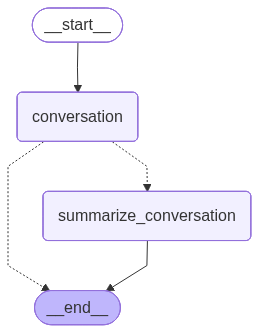

In [10]:
from IPython.display import Image, display
from langgraph.graph import START, StateGraph

builder = StateGraph(State)
builder.add_node('conversation', call_model)
builder.add_node('summarize_conversation', summarize_conversation)

builder.add_edge(START, 'conversation')
builder.add_conditional_edges('conversation', should_continue)
builder.add_edge('summarize_conversation', END)

graph = builder.compile(checkpointer = memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
config = {"configurable": {"thread_id":1}}

resp = graph.invoke({'messages': [HumanMessage(content = "Hi, What's my name?")]}, config)

for m in resp['messages'][-1:]:
  print(m.content[0]['text'])

Your name is Lance! And I know you're a big fan of the San Francisco 49ers. 

How can I help you today, Lance? We can talk about the 49ers or anything else you'd like!


In [ ]:
resp = graph.invoke({'messages': [HumanMessage(content = "?")]}, config)

for m in resp['messages'][-1:]:
  print(m.content[0]['text'])

In [12]:
resp = graph.invoke({'messages': [HumanMessage(content = "Hows their recent form?")]}, config)

for m in resp['messages'][-1:]:
  print(m.content[0]['text'])

The 2024 season was a highly challenging and ultimately disappointing one for the 49ers, especially coming off their Super Bowl run the year before. 

Their "form" took a massive hit, largely due to an relentless wave of injuries to key players. Here is a breakdown of how things went:

*   **The Record:** The 49ers finished the 2024 regular season with a **6-11 record**, placing them last in the NFC West and causing them to miss the playoffs entirely. 
*   **The Injury Plague:** It felt like they couldn't catch a break. Christian McCaffrey missed the first half of the season with bilateral Achilles tendinitis. Star wide receiver Brandon Aiyuk suffered a torn ACL and MCL in October, ending his season. Deebo Samuel, George Kittle, Trent Williams, and quarterback Brock Purdy all missed time or played through significant injuries. The defense also lost key pieces like safety Talanoa Hufanga and defensive tackle Javon Hargrave early on.
*   **On-Field Struggles:** Because of the constant ro

In [ ]:
resp